## Question 1

Compute the derivative of the following function using SymPy.

In [20]:
from sympy import symbols, diff, exp, ln, cot, cos, sin, tan, sqrt, acos, atan

# Define symbolic variable
x = symbols('x')

In [10]:
# Define the functions
y = x**2 + 2*x + 1

# Calculate the derivative
diff(y, x)

2*x + 2

In [11]:
# Define the functions
y = (3*x - 5)**3

# Calculate the derivative
diff(y, x)

9*(3*x - 5)**2

In [12]:
# Define the functions
y = (sqrt(x) - 1)**2 - (x**2 + 1)**4

# Calculate the derivative
diff(y, x)

-8*x*(x**2 + 1)**3 + (sqrt(x) - 1)/sqrt(x)

In [16]:
# Define the functions
y = 7*cot(x) - 8*acos(x)

# Calculate the derivative
diff(y, x)

-7*cot(x)**2 - 7 + 8/sqrt(1 - x**2)

In [17]:
# Define the functions
y = x - ln(x) +7

# Calculate the derivative
diff(y, x)

1 - 1/x

In [18]:
# Define the functions
y = -10*exp(x) + 5**x - 5*x + x/5

# Calculate the derivative
diff(y, x)

5**x*log(5) - 10*exp(x) - 24/5

In [19]:
# Define the functions
y = 2*sin(x) / (sin(x) - cos(x))

# Calculate the derivative
diff(y, x)

2*(-sin(x) - cos(x))*sin(x)/(sin(x) - cos(x))**2 + 2*cos(x)/(sin(x) - cos(x))

In [21]:
# Define the functions
y = x**2 * ln(x) / (1 - atan(x))

# Calculate the derivative
diff(y, x)

x**2*log(x)/((1 - atan(x))**2*(x**2 + 1)) + 2*x*log(x)/(1 - atan(x)) + x/(1 - atan(x))

## Question 2

Use least square method to find the parameter for the following models:

The following cell shows how the initial data is created.

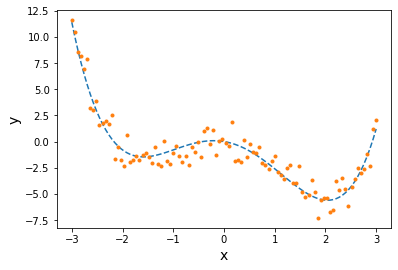

In [34]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1358)
X = np.linspace(-3,3, 100)
y_true = 0.3 * x**4 -0.1 * x**3 - 2* x**2 - 0.8*x
Y = y_true + np.random.randn(len(x))
plt.plot(X,y_true, '--')
plt.plot(X,Y, '.')
plt.xlabel('x', size=14)
plt.ylabel('y', size=14)

plt.savefig('dataGenerate.jpg')

### First model:

Now we want to find the parameters of the following model to fit it to the data.

$y=a_1 x +a_0$

In [44]:
import sympy as sp

# Variables for the linear equation: y = a1x + a0
a1, a0 = sp.symbols('a1 a0')

# Sum of squared differences between observed and predicted y-values
error = sum((a1 * x + a0 - y)**2 for x, y in zip(X,Y))

# Finding partial derivatives of the error function with respect to a1 and a0
partial_a1 = sp.diff(error, a1)
partial_a0 = sp.diff(error, a0)

# Solving the system of equations to minimize the error (least squares solution)
solution = sp.solve((partial_a1, partial_a0), (a1, a0))

best_fit_a1, best_fit_a0 = solution[a1], solution[a0]


print(f"The model is y = {best_fit_a1}x + {best_fit_a0}")

The model is y = -1.31745895844509x + -1.06551758405773


Now, let's compare the model's output with the data used to fit the model.

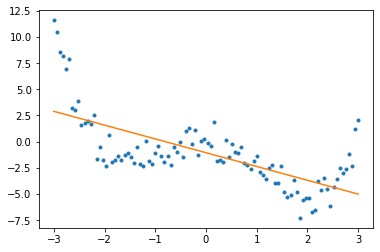

In [45]:
import numpy as np

# Find the model output
X_grid = np.linspace(-3, 3, 1000)
Y_model = best_fit_a1 * X_grid + best_fit_a0

plt.plot(X,Y, '.')
plt.plot(X_grid, Y_model)

plt.show()

Let's compute the squared error to evaluate the fitted model.

In [49]:
# Cost value
error = sum((best_fit_a1 * x + best_fit_a0 - y)**2 for x, y in zip(X,Y))
print("Square error:", error)

Square error: 614.825349222346


### Second model:

$y=a_2 x^2 +a_1 x + a_0$

In [53]:
import sympy as sp

# Variables for the linear equation: y = a2x^2 + a1 x + a0
a2, a1, a0 = sp.symbols('a2 a1 a0')

# Sum of squared differences between observed and predicted y-values
error = sum((a2 * x**2 + a1 * x + a0 - y)**2 for x, y in zip(X,Y))

# Finding partial derivatives of the error function with respect to a2, a1 and a0
partial_a2 = sp.diff(error, a2)
partial_a1 = sp.diff(error, a1)
partial_a0 = sp.diff(error, a0)

# Solving the system of equations to minimize the error (least squares solution)
solution = sp.solve((partial_a2, partial_a1, partial_a0), (a2, a1, a0))

best_fit_a2, best_fit_a1, best_fit_a0 = solution[a2], solution[a1], solution[a0]


print(f"The model is y = {best_fit_a2}x^2 + {best_fit_a1}x + {best_fit_a0}")

The model is y = 0.410513483953173x^2 + -1.31745895844509x + -2.32193764100532


Now, let's compare the model's output with the data used to fit the model.

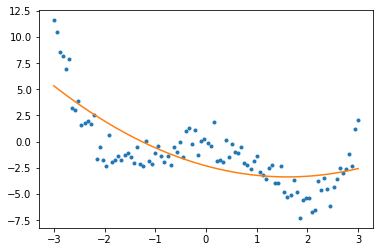

In [55]:
import numpy as np

# Find the model output
X_grid = np.linspace(-3, 3, 1000)
Y_model = best_fit_a2 * X_grid**2 + best_fit_a1 * X_grid + best_fit_a0

plt.plot(X,Y, '.')
plt.plot(X_grid, Y_model)

plt.show()

Let's compute the squared error to evaluate the fitted model.

In [57]:
# Cost value
error = sum((best_fit_a2 * x**2 + best_fit_a1 * x + best_fit_a0 - y)**2 for x, y in zip(X,Y))
print("Square error:", error)

Square error: 488.575930443957


### Third model:

$y=a_3 x^3 + a_2 x^2 +a_1 x + a_0$

In [59]:
import sympy as sp

# Variables for the linear equation: y = a2x^2 + a1 x + a0
a3, a2, a1, a0 = sp.symbols('a3 a2 a1 a0')

# Sum of squared differences between observed and predicted y-values
error = sum((a3 * x**3 + a2 * x**2 + a1 * x + a0 - y)**2 for x, y in zip(X,Y))

# Finding partial derivatives of the error function with respect to a3, a2, a1 and a0
partial_a3 = sp.diff(error, a3)
partial_a2 = sp.diff(error, a2)
partial_a1 = sp.diff(error, a1)
partial_a0 = sp.diff(error, a0)

# Solving the system of equations to minimize the error (least squares solution)
solution = sp.solve((partial_a3, partial_a2, partial_a1, partial_a0), (a3, a2, a1, a0))

best_fit_a3, best_fit_a2, best_fit_a1, best_fit_a0 = solution[a3], solution[a2], solution[a1], solution[a0]


print(f"The model is y = {best_fit_a3}x^3 + {best_fit_a2}x^2 + {best_fit_a1}x + {best_fit_a0}")

The model is y = -0.144440966027100x^3 + 0.410513483953173x^2 + -0.521826654670835x + -2.32193764100532


Now, let's compare the model's output with the data used to fit the model.

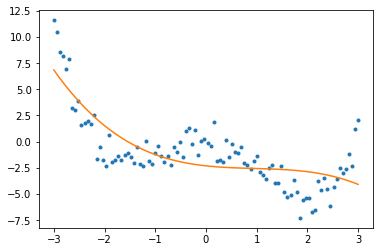

In [60]:
import numpy as np

# Find the model output
X_grid = np.linspace(-3, 3, 1000)
Y_model = best_fit_a3 * X_grid**3 + best_fit_a2 * X_grid**2 + best_fit_a1 * X_grid + best_fit_a0

plt.plot(X,Y, '.')
plt.plot(X_grid, Y_model)

plt.show()

Let's compute the squared error to evaluate the fitted model.

In [61]:
# Cost value
error = sum((best_fit_a3 * x**3 + best_fit_a2 * x**2 + best_fit_a1 * x + best_fit_a0 - y)**2 for x, y in zip(X,Y))
print("Square error:", error)

Square error: 451.702728927695


### Fourth model:

$y=a_4 x^4 + a_3 x^3 + a_2 x^2 +a_1 x + a_0$

In [63]:
import sympy as sp

# Variables for the linear equation: y = a2x^2 + a1 x + a0
a4, a3, a2, a1, a0 = sp.symbols('a4 a3 a2 a1 a0')

# Sum of squared differences between observed and predicted y-values
error = sum((a4 * x**4 + a3 * x**3 + a2 * x**2 + a1 * x + a0 - y)**2 for x, y in zip(X,Y))

# Finding partial derivatives of the error function with respect to a4, a3, a2, a1 and a0
partial_a4 = sp.diff(error, a4)
partial_a3 = sp.diff(error, a3)
partial_a2 = sp.diff(error, a2)
partial_a1 = sp.diff(error, a1)
partial_a0 = sp.diff(error, a0)

# Solving the system of equations to minimize the error (least squares solution)
solution = sp.solve((partial_a4, partial_a3, partial_a2, partial_a1, partial_a0), (a4, a3, a2, a1, a0))

best_fit_a4, best_fit_a3, best_fit_a2, best_fit_a1, best_fit_a0 = solution[a4], solution[a3], solution[a2], solution[a1], solution[a0]


print(f"The model is y = {best_fit_a4}x^4 + {best_fit_a3}x^3 + {best_fit_a2}x^2 + {best_fit_a1}x + {best_fit_a0}")

The model is y = 0.295887429304493x^4 + -0.144440966027100x^3 + -1.91738270981669x^2 + -0.521826654670834x + -0.185503581942679


Now, let's compare the model's output with the data used to fit the model.

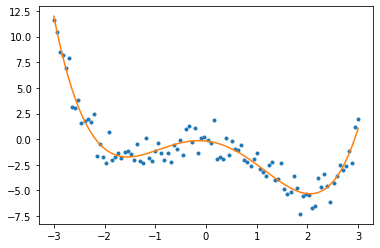

In [64]:
import numpy as np

# Find the model output
X_grid = np.linspace(-3, 3, 1000)
Y_model = best_fit_a4 * X_grid**4 + best_fit_a3 * X_grid**3 + best_fit_a2 * X_grid**2 + best_fit_a1 * X_grid + best_fit_a0

plt.plot(X,Y, '.')
plt.plot(X_grid, Y_model)

plt.show()

Let's compute the squared error to evaluate the fitted model.

In [65]:
# Cost value
error = sum((best_fit_a4 * x**4 + best_fit_a3 * x**3 + best_fit_a2 * x**2 + best_fit_a1 * x + best_fit_a0 - y)**2 for x, y in zip(X,Y))
print("Square error:", error)

Square error: 91.4234927691503


### Fifth model:

$y=a_4 x^4 + a_3 x^3 + a_2 x^2 +a_1 x + a_0$

In [66]:
import sympy as sp

# Variables for the linear equation: y = a2x^2 + a1 x + a0
a5, a4, a3, a2, a1, a0 = sp.symbols('a5 a4 a3 a2 a1 a0')

# Sum of squared differences between observed and predicted y-values
error = sum((a5 * x**5 + a4 * x**4 + a3 * x**3 + a2 * x**2 + a1 * x + a0 - y)**2 for x, y in zip(X,Y))

# Finding partial derivatives of the error function with respect to a5, a4, a3, a2, a1 and a0
partial_a5 = sp.diff(error, a5)
partial_a4 = sp.diff(error, a4)
partial_a3 = sp.diff(error, a3)
partial_a2 = sp.diff(error, a2)
partial_a1 = sp.diff(error, a1)
partial_a0 = sp.diff(error, a0)

# Solving the system of equations to minimize the error (least squares solution)
solution = sp.solve((partial_a5, partial_a4, partial_a3, partial_a2, partial_a1, partial_a0), (a5, a4, a3, a2, a1, a0))

best_fit_a5, best_fit_a4, best_fit_a3, best_fit_a2, best_fit_a1, best_fit_a0 = solution[a5], solution[a4], solution[a3], solution[a2], solution[a1], solution[a0]


print(f"The model is y = {best_fit_a5}x^5  + {best_fit_a4}x^4 + {best_fit_a3}x^3 + {best_fit_a2}x^2 + {best_fit_a1}x + {best_fit_a0}")

The model is y = 0.0127947770141101x^5  + 0.295887429304492x^4 + -0.274895212228509x^3 + -1.91738270981668x^2 + -0.265342015553682x + -0.185503581942680


Now, let's compare the model's output with the data used to fit the model.

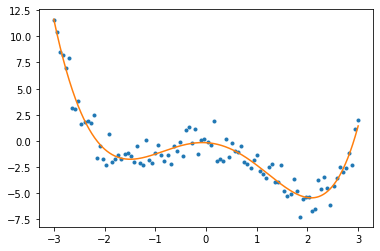

In [67]:
import numpy as np

# Find the model output
X_grid = np.linspace(-3, 3, 1000)
Y_model = best_fit_a5 * X_grid**5 + best_fit_a4 * X_grid**4 + best_fit_a3 * X_grid**3 + best_fit_a2 * X_grid**2 + best_fit_a1 * X_grid + best_fit_a0

plt.plot(X,Y, '.')
plt.plot(X_grid, Y_model)

plt.show()

Let's compute the squared error to evaluate the fitted model.

In [68]:
# Cost value
error = sum((best_fit_a5 * x**5 + best_fit_a4 * x**4 + best_fit_a3 * x**3 + best_fit_a2 * x**2 + best_fit_a1 * x + best_fit_a0 - y)**2 for x, y in zip(X,Y))
print("Square error:", error)

Square error: 89.8652271612949


As you can see, the squared error for the models decreases significantly up to model 4. However, there is only a small difference between the fourth and fifth models, so it seems that the fourth model, considering both accuracy and complexity, is the best fit. If you consider how the data were created, it is evident that the data were generated using a polynomial of degree 4, which further confirms that the fourth model is the best fit for this data. Nevertheless, note that we don't know how the data were created when planning to fit the model. This means that we must always use evaluation metrics to determine which model fits best.

## Question 3

Find the limits of the following function using SymPy.

In [26]:
from sympy import limit, sin, cos, oo, sqrt

# Define symbolic variable
x = symbols('x')

In [27]:
# Define function
y = (x -2)/(x**2 + 2*x +1)

# calculate the limit as x approaches 2
limit(y, x, 2)

0

In [28]:
# Define function
y = (x**3 + 3*x**2 + 5)/(x**2 - x - 6)

# calculate the limit as x approaches -2
limit(y, x, -2)

-oo

In [29]:
# Define function
y = (sqrt(x**2 + 1) + x)**2 / ((x**6 + 1 ) ** (1/3))

# calculate the limit as x approaches oo
limit(y, x, oo)

4

In [30]:
# Define function
y = sin(10*x) / (10*x)

# calculate the limit as x approaches 0
limit(y, x, 0)

1

In [31]:
# Define function
y = x / sqrt(1 - cos(x))

# calculate the limit as x approaches 0
limit(y, x, 0)

sqrt(2)